In [42]:
# 1. Train a Traditional XGBoost Baseline (using TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset, Dataset, DatasetDict
import torch

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [3]:
from pathlib import Path

# 1. Get the directory where THIS script is saved
# .resolve() ensures we have the full absolute path
base_dir = Path.cwd()

# 2. Define your file paths using the / operator
# Pathlib automatically handles Windows vs Mac/Linux slashes
df_path = base_dir / "data/processed_data/all_data.csv"


In [10]:
df = pd.read_csv(df_path, index_col=0)

In [11]:
df.head()

,Description,Source,Rent
0,WF Credit Card AUTO PAY 260102 OOOOO OOOOO,real,0
1,WF Credit Card AUTO PAY 260101 OOOOO OOOOO,real,0
2,ZELLE FROM OOOOO ON 12/26 REF # COF2H8DF53VH K...,real,0
3,FEDERAL NATIONAL PAYROLL 251226 939238644926DV...,real,0
4,BENEFIT PAYMENT EDI PYMNTS OOOOO OOOOO,real,0


In [16]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=34783, stratify=df[['Source', 'Rent']])

In [19]:
df_train.shape, df_test.shape

((8401, 3), (2101, 3))

In [17]:
df_train.head()

,Description,Source,Rent
1598,RENT: UNIT 304,synthetic,1
9118,Domicile disbursement,synthetic,1
8973,Property remittance for residential unit,synthetic,1
3822,Monthly on 15th,synthetic,0
2589,UTILITY - AUTO,synthetic,0


In [49]:
df_train['Rent'].value_counts(), df_test['Rent'].value_counts()

(Rent
 0    4387
 1    4014
 Name: count, dtype: int64,
 Rent
 0    1097
 1    1004
 Name: count, dtype: int64)

In [ ]:

# Assume `df_train` and `df_test` are your DataFrames with 'Description' and 'rent'
vectorizer = TfidfVectorizer(max_features=1000) # Limit features for efficiency
X_train_tfidf = vectorizer.fit_transform(df_train['Description'])
X_test_tfidf = vectorizer.transform(df_test['Description'])

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train_tfidf, df_train['Rent'])
y_pred_traditional = clf.predict(X_test_tfidf)


Traditional Model (TF-IDF + RandomForest) Performance:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1097
           1       0.95      0.84      0.89      1004

    accuracy                           0.91      2101
   macro avg       0.91      0.90      0.90      2101
weighted avg       0.91      0.91      0.90      2101



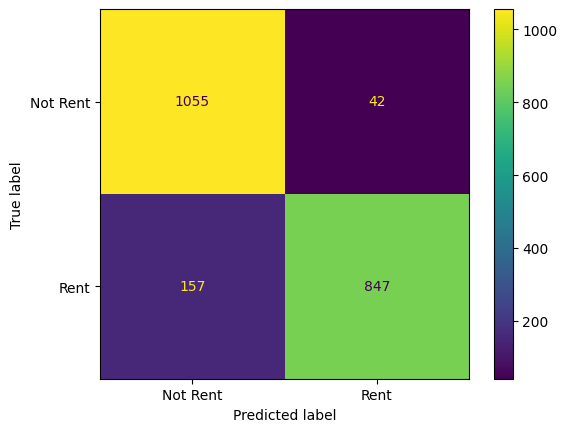

In [37]:


# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(df_test['Rent'], y_pred_traditional, display_labels=["Not Rent", "Rent"])
plt.show()


In [45]:
cm_traditional = confusion_matrix(df_test['Rent'], y_pred_traditional)

# 3. Extract the TP, TN, FP, FN values
# You can unpack the matrix or access elements by index
TN, FP, FN, TP = cm_traditional.ravel()

print(f"\nTN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

# 4. Calculate the rates using the formulas
# False Positive Rate (FPR) = FP / (FP + TN)
# False Negative Rate (FNR) = FN / (FN + TP)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")


TN: 1055, FP: 42, FN: 157, TP: 847
False Positive Rate (FPR): 0.0383
False Negative Rate (FNR): 0.1564


In [38]:

print("Traditional Model (TF-IDF + RandomForest) Performance:")
print(classification_report(df_test['Rent'], y_pred_traditional))


Traditional Model (TF-IDF + RandomForest) Performance:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1097
           1       0.95      0.84      0.89      1004

    accuracy                           0.91      2101
   macro avg       0.91      0.90      0.90      2101
weighted avg       0.91      0.91      0.90      2101



# 2. Train a Transformer-Based Model (using Hugging Face Transformers)

In [25]:

model_name = "distilbert-base-uncased"  # Good starting point for text classification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)  # Binary classification
tokenizer = AutoTokenizer.from_pretrained(model_name)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(df_train)
validation_dataset = Dataset.from_pandas(df_test)

# Combine into a DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset
})

In [33]:
def preprocess_function(examples):
    # Tokenize the transaction descriptions. Use truncation and padding for uniform length.
    return tokenizer(examples['Description'], truncation=True, padding='max_length', max_length=128)

# Apply the tokenization to the entire dataset
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# Step 4: Format for PyTorch
# Rename the 'label' column to 'labels' (expected by the Trainer)
tokenized_dataset = tokenized_dataset.rename_column('Rent', 'labels')
# Set the format to return PyTorch tensors
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/8401 [00:00<?, ? examples/s]

Map:   0%|          | 0/2101 [00:00<?, ? examples/s]

In [34]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    """Function to compute accuracy and F1 score during evaluation."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')  # Use 'macro' for multi-class
    return {'accuracy': acc, 'f1': f1}

# Step 5: Define Training Arguments
training_args = TrainingArguments(
    output_dir='./rent_classifier_results',  # Where to save the model
    eval_strategy='epoch',             # Evaluate at the end of each epoch
    save_strategy='epoch',                   # Save a checkpoint each epoch
    learning_rate=2e-5,                      # Standard learning rate for fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,                      # Number of training epochs
    weight_decay=0.01,
    load_best_model_at_end=True,             # Load the best model at the end
    metric_for_best_model='f1',              # Use F1 score to choose the best model
    push_to_hub=False,                       # Set to True if you want to upload to Hugging Face Hub
)

# Step 6: Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 7: Train the Model
trainer.train()

/var/folders/8x/6jjxqd7n5gj_5yxg2wdp9gkw0000gn/T/ipykernel_16501/226895045.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.276400,0.188722,0.905759,0.894569
2,0.187200,0.176310,0.905283,0.892024
3,0.178800,0.178884,0.908139,0.897613


TrainOutput(global_step=1578, training_loss=0.21219683176966522, metrics={'train_runtime': 1250.6344, 'train_samples_per_second': 20.152, 'train_steps_per_second': 1.262, 'total_flos': 834643962081792.0, 'train_loss': 0.21219683176966522, 'epoch': 3.0})

In [39]:
# Get predictions on the validation set
y_pred_transformer = trainer.predict(tokenized_dataset['validation'])

# 'output' contains predictions (logits), label_ids, and metrics
logits_transformer = y_pred_transformer.predictions
true_labels_transformer = y_pred_transformer.label_ids

# Convert logits to class predictions (0 or 1)
pred_labels_transformer = np.argmax(logits_transformer, axis=1)


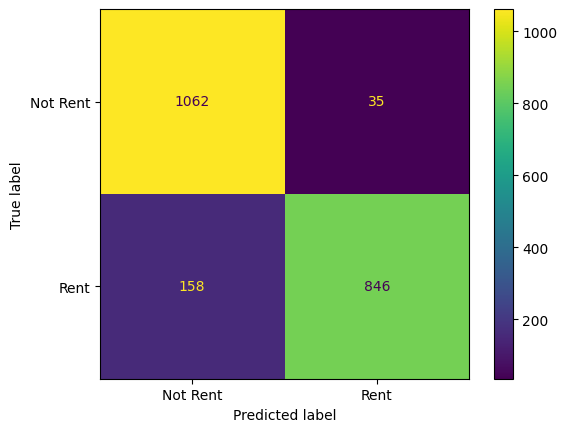

In [40]:


# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(true_labels_transformer, pred_labels_transformer, display_labels=["Not Rent", "Rent"])
plt.show()


In [43]:
cm_transformer = confusion_matrix(true_labels_transformer, pred_labels_transformer)

# 3. Extract the TP, TN, FP, FN values
# You can unpack the matrix or access elements by index
TN, FP, FN, TP = cm_transformer.ravel()

print(f"\nTN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

# 4. Calculate the rates using the formulas
# False Positive Rate (FPR) = FP / (FP + TN)
# False Negative Rate (FNR) = FN / (FN + TP)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")


TN: 1062, FP: 35, FN: 158, TP: 846
False Positive Rate (FPR): 0.0319
False Negative Rate (FNR): 0.1574


In [47]:

print("Transformer Model Performance:")
print(classification_report(true_labels_transformer, pred_labels_transformer))


Transformer Model Performance:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1097
           1       0.96      0.84      0.90      1004

    accuracy                           0.91      2101
   macro avg       0.92      0.91      0.91      2101
weighted avg       0.91      0.91      0.91      2101



In [48]:

print("Traditional Model (TF-IDF + RandomForest) Performance:")
print(classification_report(df_test['Rent'], y_pred_traditional))


Traditional Model (TF-IDF + RandomForest) Performance:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1097
           1       0.95      0.84      0.89      1004

    accuracy                           0.91      2101
   macro avg       0.91      0.90      0.90      2101
weighted avg       0.91      0.91      0.90      2101

